<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/19_program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 641ms/step - accuracy: 0.5853 - loss: 0.6751 - val_accuracy: 0.9152 - val_loss: 0.3736
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 424ms/step - accuracy: 0.9194 - loss: 0.3686 - val_accuracy: 0.9226 - val_loss: 0.3484
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 421ms/step - accuracy: 0.9226 - loss: 0.3352 - val_accuracy: 0.9226 - val_loss: 0.3113
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 595ms/step - accuracy: 0.9226 - loss: 0.3074 - val_accuracy: 0.9226 - val_loss: 0.2953
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 432ms/step - accuracy: 0.9226 - loss: 0.2941 - val_accuracy: 0.9226 - val_loss: 0.2826
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.9226 - loss: 0.2782 - val_accuracy: 0.9226 - val_loss: 0.2551
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 614ms/step - accuracy: 0.9226 - loss: 0.2433 - val_accuracy: 0.9226 - val_loss: 0.2160
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 430ms/step - accuracy: 0.9226 - loss: 0.2173 - val_accuracy: 0.9226 - val_loss

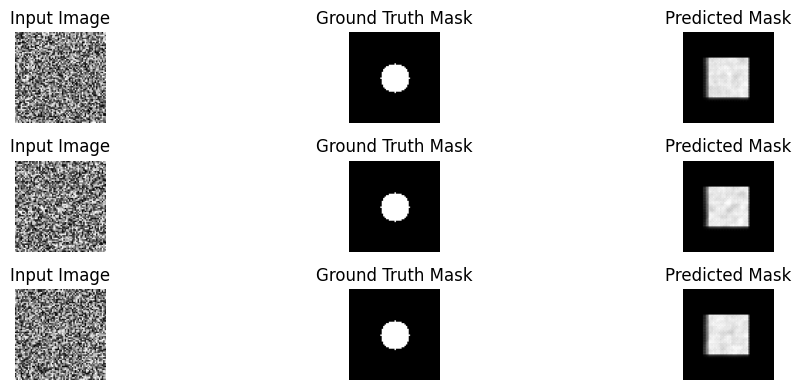

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
import matplotlib.pyplot as plt

# 1️⃣ Generate synthetic dataset (64x64 grayscale)
num_samples = 200
img_height, img_width = 64, 64

# Images: random noise with circle shapes
X = np.random.rand(num_samples, img_height, img_width, 1)

# Masks: binary circle in center
y = np.zeros((num_samples, img_height, img_width, 1))
for i in range(num_samples):
    cx, cy, r = 32, 32, 10
    Y, X_grid = np.ogrid[:img_height, :img_width]
    mask = (X_grid - cx)**2 + (Y - cy)**2 <= r**2
    y[i, mask, 0] = 1.0

# Normalize
X = X / np.max(X)

# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2️⃣ Define UNet model
def unet_model(input_size=(64,64,1)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoder
    u2 = Conv2DTranspose(32, 2, strides=(2,2), padding='same')(c3)
    u2 = concatenate([u2, c2])
    c4 = Conv2D(32, 3, activation='relu', padding='same')(u2)
    c4 = Conv2D(32, 3, activation='relu', padding='same')(c4)

    u1 = Conv2DTranspose(16, 2, strides=(2,2), padding='same')(c4)
    u1 = concatenate([u1, c1])
    c5 = Conv2D(16, 3, activation='relu', padding='same')(u1)
    c5 = Conv2D(16, 3, activation='relu', padding='same')(c5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# 3️⃣ Compile model
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4️⃣ Train model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=16)

# 5️⃣ Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.3f}")

# 6️⃣ Predict and visualize
y_pred = model.predict(X_test)

# Visualize some predictions
plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(3,3,i*3+1)
    plt.imshow(X_test[i,:,:,0], cmap='gray')
    plt.title('Input Image')
    plt.axis('off')

    plt.subplot(3,3,i*3+2)
    plt.imshow(y_test[i,:,:,0], cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.subplot(3,3,i*3+3)
    plt.imshow(y_pred[i,:,:,0], cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')
plt.tight_layout()
plt.show()
